# 01 — Exploration des données simulées

Objectif : visualiser le dataset généré par `src/data/simulator.py` (100 patients × 10 séances × 128 points EEG) avant de passer à la phase de modélisation.

Cette notebook accompagne le rapport PFE — elle sert à :
1. Confirmer la forme du dataset.
2. Comparer le signal EEG d'un répondeur et d'un non-répondeur.
3. Visualiser la trajectoire de la puissance alpha au fil des séances.
4. Comparer les spectres de puissance moyens (PSD) entre les deux groupes.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

from src.data.loader import load

ds = load(ROOT / "data" / "simulated")
print("signals:", ds.signals.shape, ds.signals.dtype)
print("labels :", ds.labels.shape, "— responders:", int(ds.labels.sum()))
print("fs     :", ds.fs, "Hz")
print("window :", ds.window, "samples (=", ds.window / ds.fs, "s)")

signals: (100, 10, 128) float32
labels : (100,) — responders: 50
fs     : 256.0 Hz
window : 128 samples (= 0.5 s)


## 1. Répartition des labels

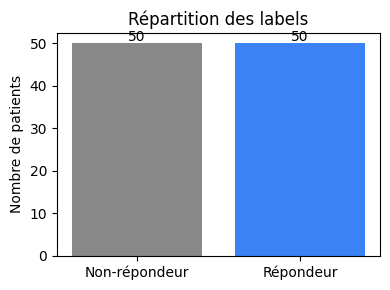

In [2]:
n_resp = int(ds.labels.sum())
n_non = len(ds.labels) - n_resp
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["Non-répondeur", "Répondeur"], [n_non, n_resp], color=["#888", "#3b82f6"])
ax.set_ylabel("Nombre de patients")
ax.set_title("Répartition des labels")
for i, v in enumerate([n_non, n_resp]):
    ax.text(i, v + 0.5, str(v), ha="center")
plt.tight_layout()
plt.show()

## 2. Exemples de signaux EEG (séance 0)

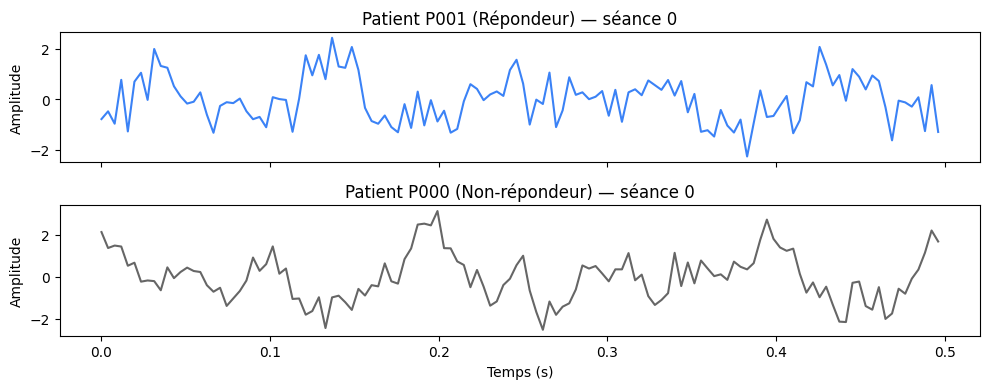

In [3]:
resp_idx = int(np.where(ds.labels == 1)[0][0])
nonresp_idx = int(np.where(ds.labels == 0)[0][0])
t = np.arange(ds.window) / ds.fs

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axes[0].plot(t, ds.signals[resp_idx, 0], color="#3b82f6")
axes[0].set_title(f"Patient P{resp_idx:03d} (Répondeur) — séance 0")
axes[0].set_ylabel("Amplitude")
axes[1].plot(t, ds.signals[nonresp_idx, 0], color="#666")
axes[1].set_title(f"Patient P{nonresp_idx:03d} (Non-répondeur) — séance 0")
axes[1].set_xlabel("Temps (s)")
axes[1].set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

## 3. Trajectoire de la puissance alpha (8–13 Hz) par séance

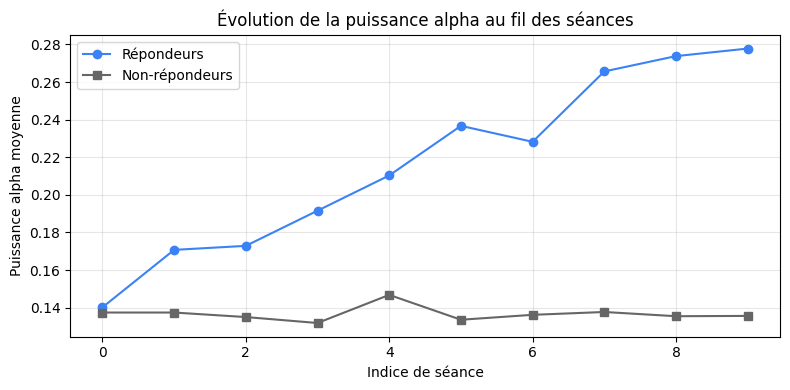

In [4]:
def alpha_power(signals_2d, fs):
    freqs, psd = welch(signals_2d, fs=fs, nperseg=signals_2d.shape[-1], axis=-1)
    mask = (freqs >= 8) & (freqs <= 13)
    return psd[..., mask].mean(axis=-1)

alpha_per_session = np.stack(
    [alpha_power(ds.signals[:, s, :], ds.fs) for s in range(ds.signals.shape[1])],
    axis=1,
)

resp_mean = alpha_per_session[ds.labels == 1].mean(axis=0)
non_mean = alpha_per_session[ds.labels == 0].mean(axis=0)
sessions = np.arange(ds.signals.shape[1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sessions, resp_mean, marker="o", color="#3b82f6", label="Répondeurs")
ax.plot(sessions, non_mean, marker="s", color="#666", label="Non-répondeurs")
ax.set_xlabel("Indice de séance")
ax.set_ylabel("Puissance alpha moyenne")
ax.set_title("Évolution de la puissance alpha au fil des séances")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. PSD moyenne — répondeurs vs non-répondeurs (dernière séance)

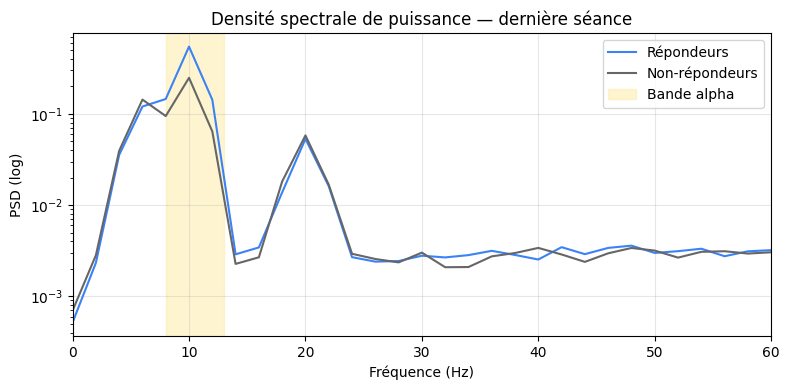

In [5]:
last = ds.signals[:, -1, :]
freqs, psd = welch(last, fs=ds.fs, nperseg=ds.window, axis=-1)
psd_resp = psd[ds.labels == 1].mean(axis=0)
psd_non = psd[ds.labels == 0].mean(axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(freqs, psd_resp, color="#3b82f6", label="Répondeurs")
ax.semilogy(freqs, psd_non, color="#666", label="Non-répondeurs")
ax.axvspan(8, 13, color="#fde68a", alpha=0.4, label="Bande alpha")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("PSD (log)")
ax.set_title("Densité spectrale de puissance — dernière séance")
ax.set_xlim(0, 60)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Score clinique simulé par groupe

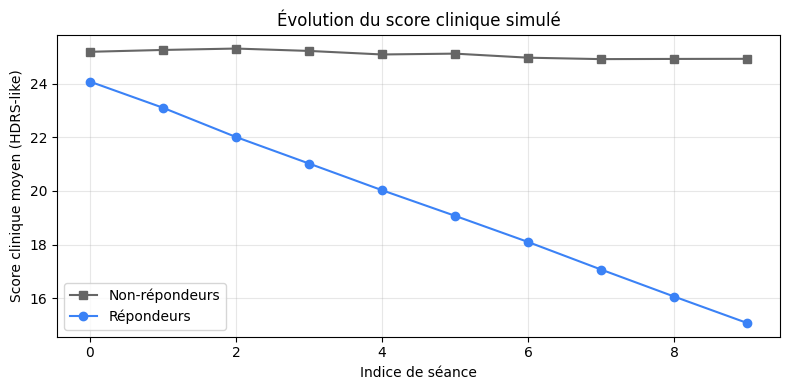

In [6]:
meta = ds.metadata
pivot = meta.pivot_table(index="session_idx", columns="label", values="score_clinique", aggfunc="mean")
pivot.columns = ["Non-répondeur", "Répondeur"] if list(pivot.columns) == [0, 1] else pivot.columns

fig, ax = plt.subplots(figsize=(8, 4))
pivot["Non-répondeur"].plot(ax=ax, marker="s", color="#666", label="Non-répondeurs")
pivot["Répondeur"].plot(ax=ax, marker="o", color="#3b82f6", label="Répondeurs")
ax.set_xlabel("Indice de séance")
ax.set_ylabel("Score clinique moyen (HDRS-like)")
ax.set_title("Évolution du score clinique simulé")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

- Le dataset présente bien la forme attendue `(100, 10, 128)` avec un label binaire équilibré.
- La puissance alpha augmente progressivement chez les répondeurs (effet thérapeutique simulé).
- Le score clinique diminue pour les répondeurs et reste stable / monte légèrement pour les non-répondeurs.
- Il y a donc un signal apprenable pour le LSTM (phase 4). Sur des données réelles, le ratio signal/bruit serait à mesurer empiriquement.